## Shapenorm in 2D for BLscale data.

Based on `fit-kpsn-blscale`. Turned into `fit-kpsn-blscale-2d`.

### Setup

In [1]:
%load_ext autoreload
%autoreload 3 --print

In [2]:
from shape_norm.project.paths import Project, create_model
from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import (
    instantiation,
    setup,
    pose,
    morph,
    util as model_util,
)
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm import pca
from blscale_loader import loader, linear_skeletal as blscale_ls
import os, sys, shutil
import numpy as np
from pprint import pprint
from matplotlib import colors as mpl_col
import jax.numpy as jnp
import itertools as iit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
import seaborn as sns
from shape_norm import viz
from shape_norm.viz import styles
from scipy.spatial.distance import jensenshannon
from tensorflow_probability.substrates import jax as tfp
from ruamel.yaml import YAML
from bidict import bidict
import matplotlib.pyplot as plt
from collections import defaultdict
import os, re
import tqdm
from cmap import Colormap
import joblib as jl

from pathlib import Path
import logging

##### Supporting functions

In [5]:

_with_match = lambda test, pattern, f: (
    f(m) if (m := re.search(pattern, test)) else None
)
_name_func = lambda path, *a: _with_match(
    path,
    r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
    lambda m: f"{m.group(1)}",
)



def raw_data_armature_meta():
    """Organize metadata on keypoints and skeleton of mouse data."""
    names = [
        "shldr",
        "back",
        "hips",
        "t_base",
        "t_tip",
        "head",
        "l_ear",
        "r_ear",
        "nose",
        "lr_knee",
        "lr_foot",
        "rr_knee",
        "rr_foot",
        "lf_foot",
        "rf_foot",
    ]
    parents = dict(
        zip(
            names,
            [
                "back",
                "hips",
                None,
                "hips",
                "t_base",
                "shldr",
                "head",
                "head",
                "head",
                "hips",
                "lr_knee",
                "hips",
                "rr_knee",
                "shldr",
                "shldr",
            ],
        )
    )
    keypt_ix = lambda name: names.index(name)
    bones = np.array(
        [(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p]
    )
    root = keypt_ix("shldr")
    bones = blscale_ls.reroot(bones, root)
    bones = bones[np.argsort(bones[:, 0])]
    return names, parents, bones, root


def blscale_dataset_2d(source_dict, scale_dict, data_dir, ref_session=None):
    """
    Create a dataset using `blscale_loader`

    Parameters
    ----------
    source_dict : str or Path
        Path to the source dictionary
    scale_dict : str or Path
        Path to the scale dictionary

    Returns
    -------
    project_config_kws : dict
        Keyword args for `loaders.arrays.setup_project_config`
    coords : dict
        Dictionary mapping session names to (unaligned) keypoint data
    scales : dict
        Dictionary mapping session names to scale bone-wise scale factors and
        uniform scale factors.
    """
    session_names = loader.find_sessions(
        sources=source_dict,
        scales=scale_dict,
        ext=".npy",
        name_func=_name_func,
    )
    session_bodies = {s: f"body-{s}" for s in session_names}

    # skeleton without dropped keypoints
    names, parents, bones, root = raw_data_armature_meta()

    coords, _, _ = loader.external_scale(
        data_dir,
        sources=source_dict,
        scales=scale_dict,
        bones=bones,
        root_keypoint_ix=root,
        ext=".npy",
        name_func=_name_func,
    )
    _, scales = loader._align_scales_sources(
        source_dict, scale_dict, ext=".npy", name_func=_name_func
    )

    ref_session = list(coords.keys())[0]

    project_config_kws = {
        "session_names": list(coords.keys()),
        "bodies": session_bodies,
        "ref_session": ref_session,
        "keypoint_names": names,
        "keypoint_parents": parents,
    }

    # Drop vertical coordinate
    coords = {
        s: arr[:, :, [0, 1]]
        for s, arr in coords.items()
    }

    return project_config_kws, coords, scales

### Generate dataset

##### Load and generate

In [20]:
# As in `small-blscale-tests.ipynb`, but using `blscale_dataset_2d`

# save out blscale data
if True:
    base = '3'
    blscale_arrays_dir = Path(f"/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays-2d/{base}wk-to-all_ntt-norm")

    blscale_dir = Path('/Users/kaifox/projects/mph/data_explore/testsets/blscale-dicts')
    data_dir = Path("/Users/kaifox/projects/mph/data_explore/data")
    
    source_dict = blscale_dir / "source-dicts" / "cohort-wise" / f"{base}wk-to-all.yaml"
    # scale_dict = blscale_dir / "scale-dicts" / f"all-to-named-age_unnormed.yaml"
    scale_dict = blscale_dir / "scale-dicts" / "cohort-wise" / f"{base}wk-to-all_ntt-norm.yaml"

    project_config_kws, dataset_keypoints, scales = blscale_dataset_2d(source_dict, scale_dict, data_dir, ref_session=f'{base}wk_3bod_m0')
    _, _, bones, root = raw_data_armature_meta()

    for s in dataset_keypoints:
        np.save(blscale_arrays_dir / f"{s}.npy", dataset_keypoints[s])
    
    YAML().dump({
        "source_dict_path": str(source_dict),
        "scale_dict_path": str(scale_dict),
        "source_dict": YAML(typ='safe').load(source_dict),
        "scale_dict": YAML(typ='safe').load(scale_dict),
        "applied_scales": scales,
        "armature": {'bones': bones.tolist(), 'root': root},
        "project_config_kws": project_config_kws,
    }, open(blscale_arrays_dir / "metadata.yml", 'w'))

Loading keypoints: 100%|█████████████████| 4/4 [00:00<00:00, 665.58it/s]


Sessions: ['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3']


#### Validate

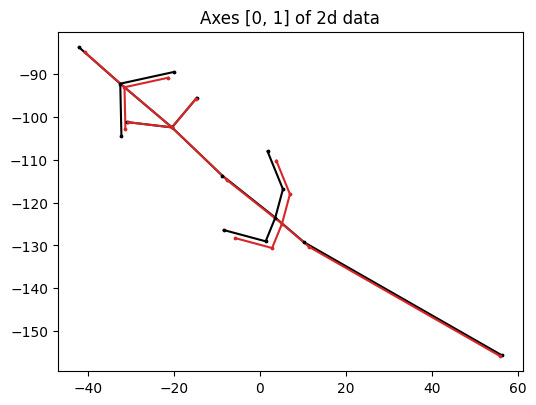

In [28]:
base = '3'
blscale_arrays_dir = Path(f"/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays-2d/{base}wk-to-all_ntt-norm")
s1 = '3wk_3bod_m0'
s2 = '3wk_52bod_m0'
frame = 1000

keypts_s1 = np.load(blscale_arrays_dir / f"{s1}.npy")
keypts_s2 = np.load(blscale_arrays_dir / f"{s2}.npy")
names, parents, bones, root = raw_data_armature_meta()
arms = Armature(names, bones, root, [], [])


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.title("Axes [0, 1] of 2d data")
viz.util.plot_mouse(ax, keypts_s1[frame], arms, 0, 1, 'k')
viz.util.plot_mouse(ax, keypts_s2[frame], arms, 0, 1, 'C3')

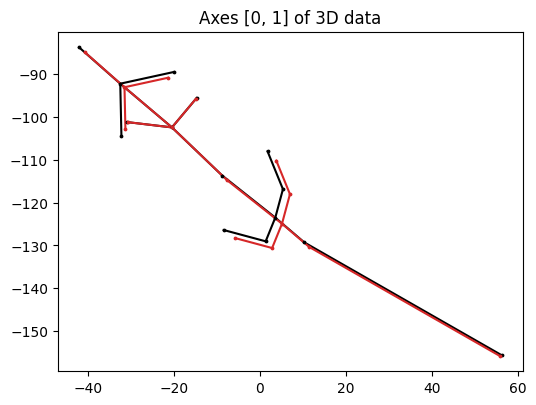

In [29]:
base = '3'
blscale_arrays_dir = Path(f"/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays/{base}wk-to-all_ntt-norm")
s1 = '3wk_3bod_m0'
s2 = '3wk_52bod_m0'
frame = 1000

keypts_s1 = np.load(blscale_arrays_dir / f"{s1}.npy")
keypts_s2 = np.load(blscale_arrays_dir / f"{s2}.npy")
names, parents, bones, root = raw_data_armature_meta()
arms = Armature(names, bones, root, [], [])


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.title("Axes [0, 1] of 3D data")
viz.util.plot_mouse(ax, keypts_s1[frame], arms, 0, 1, 'k')
viz.util.plot_mouse(ax, keypts_s2[frame], arms, 0, 1, 'C3')

### Run

In [3]:
blscale_arrays_dir = Path(
    "/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays-2d/3wk-to-all_ntt-norm"
)
project_dir = Path(
    "/Users/kaifox/projects/mph/generative_api/test/projects/blscale-script/2d"
)

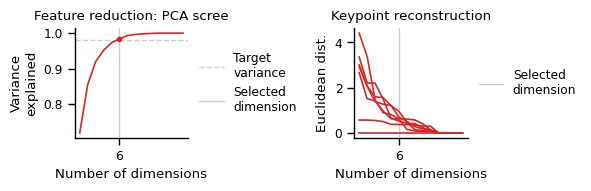

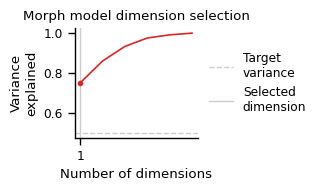

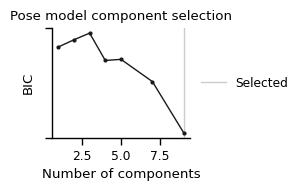

In [8]:
ref_age = "3"
tgt_ages = ["7", "52"]
animals = ["0", "1"]
sessions = [
    f"{ref_age}wk_{t}bod_m{a}" for a in animals for t in [ref_age] + tgt_ages
]
names, parents, _, _ = raw_data_armature_meta()
project_config_kws = dict(
    filepaths={s: blscale_arrays_dir / f"{s}.npy" for s in sessions},
    keypoint_names=names,
    keypoint_parents=parents,
    bodies={s: f"body-{s}" for s in sessions},
    ref_session=f"{ref_age}wk_52bod_m1",
)

project_dir.mkdir(exist_ok=True)
project = Project(project_dir)

plot_dir = project_dir / "plots"
plot_dir.mkdir(exist_ok=True)
plotter, colors = styles.init_nb(
    str(plot_dir),
    style="default",
    fmt="pdf",
    display=False,
)


### -------------------------  Calibration / training  ------------------------

loaders.raw_npy.setup_project_config(
    project.main_config(),
    feature_type="pcs",
    alignment_type="sagittal",
    exclude_keypoints=[
        "t_base",
        "lr_knee",
        "lr_foot",
        "rr_knee",
        "rr_foot",
        "lf_foot",
        "rf_foot",
        "t_tip",
    ],
    subsample_to=40,
    **project_config_kws,
)

setup.setup_base_model_config(
    project.main_config(), project.base_model_config()
)

# --- calibration: alignment and feature reduction
cfg = config.load_project_config(project.main_config())
dataset = loaders.load_dataset(cfg["dataset"])
cfg["features"]["calibration"]["tgt_variance"] = 0.98

dataset, cfg = alignment.sagittal.calibrate(
    dataset, cfg, origin="hips", anterior="head"
)

cfg = features.pcs.calibrate(dataset, cfg)
dataset = features.reduce_to_features(dataset, cfg["features"])
config.save_project_config(project.main_config(), cfg, write_calib=True)

# --- calibration: pose and morph models
cfg = config.load_model_config(project.base_model_config())
cfg["morph"]["prior_mode"] = "distance"
cfg["morph"]["calibration"]["tgt_variance"] = 0.5
cfg["pose"]["calibration"]["n_iter"] = 9
cfg["pose"]["calibration"]["max_components"] = 10
cfg["pose"]["subj_weight_uniformity"] = 1
cfg["fit"]["n_steps"] = 1000
cfg["fit"]["learning_rate"] = dict(kind="stair", hl=250, lr=5e-1, min=1e-5)
cfg["fit"]["mstep"]["tol"] = None
cfg["fit"]["update_scales"] = {"pose/*": 1e1}

cfg = pose.gmm.calibrate_base_model(dataset, cfg)
cfg = morph.lowrank_affine.calibrate_base_model(dataset, cfg)
cfg = em.calibrate_base_model(dataset, cfg)
config.save_model_config(project.base_model_config(), cfg, write_calib=True)


# plotting calibration
cfg = config.load_model_config(project.base_model_config())

fig = features.pcs.plot_calibration(cfg)
plotter.finalize(fig, "feature_calibration")

figs = viz.model.plot_calibration(cfg)
plotter.finalize(figs["morph"], "morph_calibration")
plotter.finalize(figs["pose"], "pose_calibration")


# set up parameter scan
scan_cfg, model_cfg = scans.setup_scan_config(
    project,
    "morph-prior-scan",
    {
        "morph.dist_var": [1e-1, 8e-1, 3e2],
        "fit.em.learning_rate.lr": [1e0, 8e-1, 8e-1],
        "fit.em.n_steps": [100, 100, 100],
    },
)

# Load data and prep for training
cfg = config.load_project_config(project.main_config())
scan_cfg = config.load_config(project.scan("morph-prior-scan") / "scan.yml")
dataset = loaders.load_dataset(cfg["dataset"])
scan_dataset, split_meta, _ = scans.prepare_scan_dataset(
    dataset, project, "morph-prior-scan", return_session_inv=True
)


# Run parameter scan!
scans.run_scan(
    project, "morph-prior-scan", scan_dataset, log_every=20, force_restart=True
)